<a href="https://colab.research.google.com/github/qaiserfatmi/Dengue/blob/main/Dengue_ML_Analysis_New_Corrected.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Data Analysis for Dengue from following published Paper**

Iqbal NT, Ahmed K, Khalid A, Imtiaz
K, Ali QM, Munir T, et al. (2025) Clinical
characteristics and serotype association of
dengue and dengue like illness in Pakistan.
PLoS Negl Trop Dis 19(5): e0012978. https://
doi.org/10.1371/journal.pntd.0012978

**Step 1 — Install and import required packages**

In [65]:
!pip install -q xgboost openpyxl mlxtend shap umap-learn

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)

from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.metrics import silhouette_score

from xgboost import XGBClassifier, XGBRegressor

import shap
import warnings
warnings.filterwarnings("ignore")

**Step 2 — Upload the Excel file**

In [5]:
# Use if you want to Browse File from computer

#from google.colab import files
#uploaded = files.upload()

In [211]:
# Use if you want to directly Read the Excel file from URL or Google colab, after uploading in content folder.

url = "https://journals.plos.org/plosntds/article/file?type=supplementary&id=10.1371/journal.pntd.0012978.s006"
df = pd.read_excel(url)
df.head()

# df = pd.read_excel("/content/journal.pntd.0012978.s006.xlsx")


,N#,Year,Aim,UWARN Sample ID,Inpatient/ Outpatient,Days of Illness,Age,Gender,Clinician I Diagnosis,Clinician II Diagnosis,...,Diarrhea,Heavy menstrual bleed,Blood in stool,Blood in urine,cough,Gum bleeding,Rash,Platelet transfusion,eGFR,Days of Hospitalization
0,0,2.0,1.0,B1-D01-21028-EDT,Outpatient,6.0,27.0,Female,Zika virus infection,Dengue without Warning Signs,...,No,No,No,No,No,No,No,No,No,0.0
1,1,2.0,1.0,B1-D01-11001-EDT,Inpatient,9.0,44.0,Female,Dengue fever,Dengue with warning signs,...,No,Yes,No,No,No,No,No,No,>60,4.0
2,2,2.0,1.0,B1-D01-11002-EDT,Inpatient,7.0,46.0,Female,Dengue fever,Dengue without Warning Signs,...,No,No,No,No,No,No,No,No,>60,2.0
3,3,2.0,1.0,B1-D01-11003-EDT,Inpatient,4.0,12.0,Female,Dengue fever,Dengue without Warning Signs,...,No,No,No,No,No,No,No,No,No,2.0
4,4,2.0,1.0,B1-D01-21001-EDT,Outpatient,5.0,40.0,Male,Acute Viral fever,Dengue with warning signs,...,No,No,No,No,No,No,No,No,>60,0.0


In [212]:
# Save dataframe as original Excel file
df.to_excel("/content/01_dengue_dataset_original.xlsx", index=False)

**Step 3 — Check dataset size, sheets, and columns**

In [70]:
df.shape

(352, 78)

In [71]:
df.head()

,N#,Year,Aim,UWARN Sample ID,Inpatient/ Outpatient,Days of Illness,Age,Gender,Clinician I Diagnosis,Clinician II Diagnosis,...,Diarrhea,Heavy menstrual bleed,Blood in stool,Blood in urine,cough,Gum bleeding,Rash,Platelet transfusion,eGFR,Days of Hospitalization
0,0,2.0,1.0,B1-D01-21028-EDT,Outpatient,6.0,27.0,Female,Zika virus infection,Dengue without Warning Signs,...,No,No,No,No,No,No,No,No,No,0.0
1,1,2.0,1.0,B1-D01-11001-EDT,Inpatient,9.0,44.0,Female,Dengue fever,Dengue with warning signs,...,No,Yes,No,No,No,No,No,No,>60,4.0
2,2,2.0,1.0,B1-D01-11002-EDT,Inpatient,7.0,46.0,Female,Dengue fever,Dengue without Warning Signs,...,No,No,No,No,No,No,No,No,>60,2.0
3,3,2.0,1.0,B1-D01-11003-EDT,Inpatient,4.0,12.0,Female,Dengue fever,Dengue without Warning Signs,...,No,No,No,No,No,No,No,No,No,2.0
4,4,2.0,1.0,B1-D01-21001-EDT,Outpatient,5.0,40.0,Male,Acute Viral fever,Dengue with warning signs,...,No,No,No,No,No,No,No,No,>60,0.0


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 352 entries, 0 to 351
Data columns (total 78 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   N#                                    350 non-null    object        
 1   Year                                  349 non-null    float64       
 2   Aim                                   349 non-null    float64       
 3   UWARN Sample ID                       349 non-null    object        
 4   Inpatient/ Outpatient                 349 non-null    object        
 5   Days of Illness                       318 non-null    float64       
 6   Age                                   349 non-null    float64       
 7   Gender                                349 non-null    object        
 8   Clinician I Diagnosis                 340 non-null    object        
 9   Clinician II Diagnosis                349 non-null    object        
 10  Fi

In [73]:
df.columns.tolist()

['N#',
 'Year ',
 'Aim',
 'UWARN Sample ID',
 'Inpatient/ Outpatient',
 'Days of Illness',
 'Age ',
 'Gender',
 'Clinician I Diagnosis',
 'Clinician II Diagnosis',
 'Final Diagnosis',
 'Sample Collection Date  (DD/MM/YYYY)',
 'Final Dx (Peter)',
 'Peter Diagnosis',
 'NS-1 antigen',
 'IgM Antibody',
 'DENV Dx Results',
 'RNaseP PCR',
 'RNaseP Cq Value',
 'DENV PCR ',
 'DENV Cq Value',
 'ZIKV PCR ',
 'ZIKV Cq Value',
 'DENV Serotype',
 'DV1',
 'DV2',
 'DV3',
 'DV4',
 ' Fever or chills ',
 'Days of Fever',
 'Fever or chills onset date',
 'Currently symptomatic?',
 'Fever or chills resolution date',
 'Weight Kg',
 'Systolic Blood Pressure',
 'Diastolic Blood Pressure',
 'Pulse',
 'Temperature (c)',
 'Respiratory rate',
 'Pulse oxygen %',
 'Hemotocrit (%)',
 'WBC_count (10^9/L)',
 'Lymph_count (%)',
 'Neut_count  (%)',
 'Hemoglobin (g/dl)',
 'Platelet        (10^9/L)',
 'Thrombocytopenia Grade',
 'NLR',
 'ALT (IU/L)',
 'AST (IU/L)',
 'BUN  (mg/dl)',
 'Creatinine     (mg/dl)',
 'BACTERIA',
 

**Step 4 — Clean column names**

In [213]:
# Store original names for comparison
original_columns = df.columns.tolist()

# Clean column names
df.columns = (
    df.columns
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", "_", regex=True)
    .str.replace(r"[^\w]", "_", regex=True)
    .str.replace(r"_+", "_", regex=True)
    .str.strip("_")
)

# Check whether cleaning created duplicate names
duplicates = df.columns[df.columns.duplicated()].tolist()

print("Cleaned columns:")
print(df.columns.tolist())

print("\nDuplicate columns:")
print(duplicates)

Cleaned columns:
['n', 'year', 'aim', 'uwarn_sample_id', 'inpatient_outpatient', 'days_of_illness', 'age', 'gender', 'clinician_i_diagnosis', 'clinician_ii_diagnosis', 'final_diagnosis', 'sample_collection_date_dd_mm_yyyy', 'final_dx_peter', 'peter_diagnosis', 'ns_1_antigen', 'igm_antibody', 'denv_dx_results', 'rnasep_pcr', 'rnasep_cq_value', 'denv_pcr', 'denv_cq_value', 'zikv_pcr', 'zikv_cq_value', 'denv_serotype', 'dv1', 'dv2', 'dv3', 'dv4', 'fever_or_chills', 'days_of_fever', 'fever_or_chills_onset_date', 'currently_symptomatic', 'fever_or_chills_resolution_date', 'weight_kg', 'systolic_blood_pressure', 'diastolic_blood_pressure', 'pulse', 'temperature_c', 'respiratory_rate', 'pulse_oxygen', 'hemotocrit', 'wbc_count_10_9_l', 'lymph_count', 'neut_count', 'hemoglobin_g_dl', 'platelet_10_9_l', 'thrombocytopenia_grade', 'nlr', 'alt_iu_l', 'ast_iu_l', 'bun_mg_dl', 'creatinine_mg_dl', 'bacteria', 'alt_class', 'ast_class', 'population_density', 'humidity', 'hospitalization', 'hypertension'

**Step 5 — Inspect important diagnostic columns**

In [214]:
for col in df.columns:
    if any(keyword in col.lower() for keyword in [
        "pcr", "ns", "igm", "igg", "diagnosis",
        "serotype", "hospital", "severity", "dengue"
    ]):
        print("\nCOLUMN:", col)
        print(df[col].value_counts(dropna=False).head(20))
        print("-" * 70)


COLUMN: clinician_i_diagnosis
clinician_i_diagnosis
Dengue fever                                                            247
Fever                                                                    30
NaN                                                                      12
Viral Fever                                                               6
Viral fever                                                               5
Suspected Dengue fever                                                    4
Dengue like illness                                                       3
Enteric fever                                                             2
URTI                                                                      2
Upper respiratory tract infection                                         2
Suspected Dengue                                                          2
Acute Gastroenteritis                                                     2
Suspected EBV reactivation         

**Step 6 — Select the correct DENV PCR column**

In [215]:
pcr_col = "denv_pcr"

df[pcr_col].value_counts(dropna=False)

,count
denv_pcr,
Positive,203
Negative,80
NaN,69


In [216]:
df.head()

,n,year,aim,uwarn_sample_id,inpatient_outpatient,days_of_illness,age,gender,clinician_i_diagnosis,clinician_ii_diagnosis,...,diarrhea,heavy_menstrual_bleed,blood_in_stool,blood_in_urine,cough,gum_bleeding,rash,platelet_transfusion,egfr,days_of_hospitalization
0,0,2.0,1.0,B1-D01-21028-EDT,Outpatient,6.0,27.0,Female,Zika virus infection,Dengue without Warning Signs,...,No,No,No,No,No,No,No,No,No,0.0
1,1,2.0,1.0,B1-D01-11001-EDT,Inpatient,9.0,44.0,Female,Dengue fever,Dengue with warning signs,...,No,Yes,No,No,No,No,No,No,>60,4.0
2,2,2.0,1.0,B1-D01-11002-EDT,Inpatient,7.0,46.0,Female,Dengue fever,Dengue without Warning Signs,...,No,No,No,No,No,No,No,No,>60,2.0
3,3,2.0,1.0,B1-D01-11003-EDT,Inpatient,4.0,12.0,Female,Dengue fever,Dengue without Warning Signs,...,No,No,No,No,No,No,No,No,No,2.0
4,4,2.0,1.0,B1-D01-21001-EDT,Outpatient,5.0,40.0,Male,Acute Viral fever,Dengue with warning signs,...,No,No,No,No,No,No,No,No,>60,0.0


In [194]:
df.shape

(352, 78)

In [217]:
# Save dataframe as Excel file after cleaning the columns
df.to_excel("/content/02_dengue_dataset_clean_column_name.xlsx", index=False)

**Step 7 — Convert DENV PCR result into binary target**

In [219]:
# It will convert positive -> 1 and negative -> 0 in new column (last column)

def convert_pcr_result(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip().lower()
    if x in ["positive", "pos", "+", "1", "1.0", "yes", "detected"]:
        return 1
    if x in ["negative", "neg", "-", "0", "0.0", "no", "not detected"]:
        return 0
    return np.nan
df["PCR_positive"] = df[pcr_col].apply(convert_pcr_result)
df["PCR_positive"].value_counts(dropna=False)

,count
PCR_positive,
1.0,203
0.0,80
NaN,69


In [197]:
# check last column with "PCR_positive" title
df.head()

,n,year,aim,uwarn_sample_id,inpatient_outpatient,days_of_illness,age,gender,clinician_i_diagnosis,clinician_ii_diagnosis,...,heavy_menstrual_bleed,blood_in_stool,blood_in_urine,cough,gum_bleeding,rash,platelet_transfusion,egfr,days_of_hospitalization,PCR_positive
0,0,2.0,1.0,B1-D01-21028-EDT,Outpatient,6.0,27.0,Female,Zika virus infection,Dengue without Warning Signs,...,No,No,No,No,No,No,No,No,0.0,1.0
1,1,2.0,1.0,B1-D01-11001-EDT,Inpatient,9.0,44.0,Female,Dengue fever,Dengue with warning signs,...,Yes,No,No,No,No,No,No,>60,4.0,0.0
2,2,2.0,1.0,B1-D01-11002-EDT,Inpatient,7.0,46.0,Female,Dengue fever,Dengue without Warning Signs,...,No,No,No,No,No,No,No,>60,2.0,1.0
3,3,2.0,1.0,B1-D01-11003-EDT,Inpatient,4.0,12.0,Female,Dengue fever,Dengue without Warning Signs,...,No,No,No,No,No,No,No,No,2.0,1.0
4,4,2.0,1.0,B1-D01-21001-EDT,Outpatient,5.0,40.0,Male,Acute Viral fever,Dengue with warning signs,...,No,No,No,No,No,No,No,>60,0.0,1.0


In [220]:
# Save dataframe as Excel file after converting denv_pcr column to binary
df.to_excel("/content/03_dengue_dataset_denv_pcr_binary.xlsx", index=False)

**Step 8 — Keep only PCR-tested patients**

In [221]:
# Remove all rows containg NaN

df_pcr = df.dropna(subset=["PCR_positive"]).copy()
df_pcr["PCR_positive"] = df_pcr["PCR_positive"].astype(int)
df_pcr["PCR_positive"].value_counts()

,count
PCR_positive,
1,203
0,80


In [222]:
# Save dataframe as Excel file after keeping denv_pcr tested (1 or 0) rows
df_pcr.to_excel("/content/04_dengue_dataset_only_denv_pcr_tested_row.xlsx", index=False)

In [201]:
df.shape

(352, 79)

In [202]:
df_pcr.shape

(283, 79)

**Step 9 — Create X (predictive variable) and y (target/outcome variable), remove leakage and unwanted columns**

In [223]:
# Target variable
y = df_pcr["PCR_positive"]

# Variables that would leak the diagnosis
leakage_keywords = [
    "pcr", "cq", "ct", "serotype", "denv",
    "diagnosis", "dx", "ns_1", "ns1",
    "igm", "igg", "final",
    "positive", "negative",
    "rnasep", "zikv",
    "dv1", "dv2", "dv3", "dv4"
]
leakage_cols = [
    col for col in df_pcr.columns
    if any(keyword in col.lower() for keyword in leakage_keywords)
]

# Administrative/sample/date columns
admin_drop_cols = [
    "n",
    "uwarn_sample_id",
    "sample_collection_date_dd_mm_yyyy",
    "fever_or_chills_onset_date",
    "fever_or_chills_resolution_date"
]

# Variables intentionally excluded
unwanted_cols = [
    "year",
    "aim",
    "age",
    "weight_kg",
    "population_density",
    "humidity",
    "associated_conditions"
]

# Outcome/management/redundant variables
extra_remove_cols = [
    "inpatient_outpatient",
    "hospitalization",
    "days_of_hospitalization",
    "platelet_transfusion",
    "currently_symptomatic",
    "days_of_illness",
    "gender"
]

# Combine all columns to remove
drop_cols = list(
    set(
        leakage_cols
        + admin_drop_cols
        + unwanted_cols
        + extra_remove_cols
    )
)

# Create predictor matrix
X = df_pcr.drop(columns=drop_cols, errors="ignore")

# Summary
print("=" * 60)
print(f"Target variable: {y.name}")
print(f"Removed {len(drop_cols)} columns")
print(f"Final X shape : {X.shape}")
print(f"Target shape  : {y.shape}")

print("\nTarget distribution:")
print(y.value_counts())

print("\nRemoved columns:")
print(sorted(drop_cols))

print("\nRemaining predictors:")
print(X.columns.tolist())

Target variable: PCR_positive
Removed 40 columns
Final X shape : (283, 39)
Target shape  : (283,)

Target distribution:
PCR_positive
1    203
0     80
Name: count, dtype: int64

Removed columns:
['PCR_positive', 'age', 'aim', 'associated_conditions', 'bacteria', 'clinician_i_diagnosis', 'clinician_ii_diagnosis', 'currently_symptomatic', 'days_of_hospitalization', 'days_of_illness', 'denv_cq_value', 'denv_dx_results', 'denv_pcr', 'denv_serotype', 'dv1', 'dv2', 'dv3', 'dv4', 'fever_or_chills_onset_date', 'fever_or_chills_resolution_date', 'final_diagnosis', 'final_dx_peter', 'gender', 'hospitalization', 'humidity', 'igm_antibody', 'inpatient_outpatient', 'n', 'ns_1_antigen', 'peter_diagnosis', 'platelet_transfusion', 'population_density', 'rnasep_cq_value', 'rnasep_pcr', 'sample_collection_date_dd_mm_yyyy', 'uwarn_sample_id', 'weight_kg', 'year', 'zikv_cq_value', 'zikv_pcr']

Remaining predictors:
['fever_or_chills', 'days_of_fever', 'systolic_blood_pressure', 'diastolic_blood_pressure',

In [224]:
# Save combined dataset: X + y
ml_ready_df = X.copy()
ml_ready_df["PCR_positive"] = y.values

ml_ready_df.to_excel("/content/05_dengue_dataset_after_column_removal.xlsx", index=False)

**Step 10 — Correct numeric-like columns before feature typing**
* Some laboratory variables may be read as text/object because they contain
* values such as "N/A", "No", ">60", or blank spaces.
* These should be corrected before separating numeric and categorical columns.

In [225]:
# Clean unusual category values before preprocessing
# Check hypertension values
print("Hypertension values before correction:")
print(X["hypertension"].value_counts(dropna=False))

# Replace unusual/incorrect hypertension category
if "hypertension" in X.columns:
    X["hypertension"] = (
        X["hypertension"]
        .replace(["bn", "BN", "Bn", "bN"], np.nan)
    )
print("\nHypertension values after correction:")
print(X["hypertension"].value_counts(dropna=False))

Hypertension values before correction:
hypertension
No     246
Yes     35
NaN      1
bn       1
Name: count, dtype: int64

Hypertension values after correction:
hypertension
No     246
Yes     35
NaN      2
Name: count, dtype: int64


In [226]:
numeric_like_cols = [
    "alt_iu_l",
    "egfr"
]

for col in numeric_like_cols:
    if col in X.columns:
        X[col] = (
            X[col]
            .astype(str)
            .str.strip()
            .replace(["N/A", "NA", "nan", "None", "", "No"], np.nan)
            .str.replace(">", "", regex=False)
        )

        X[col] = pd.to_numeric(X[col], errors="coerce")

print("Corrected numeric-like columns:")
print(X[[col for col in numeric_like_cols if col in X.columns]].dtypes)

Corrected numeric-like columns:
alt_iu_l    float64
egfr        float64
dtype: object


**Step 11 — Separate numeric and categorical features**

In [227]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool", "string"]).columns.tolist()

print("Numeric features:", len(numeric_features))
print(numeric_features)

print("\nCategorical features:", len(categorical_features))
print(categorical_features)

Numeric features: 19
['days_of_fever', 'systolic_blood_pressure', 'diastolic_blood_pressure', 'pulse', 'temperature_c', 'respiratory_rate', 'pulse_oxygen', 'hemotocrit', 'wbc_count_10_9_l', 'lymph_count', 'neut_count', 'hemoglobin_g_dl', 'platelet_10_9_l', 'nlr', 'alt_iu_l', 'ast_iu_l', 'bun_mg_dl', 'creatinine_mg_dl', 'egfr']

Categorical features: 20
['fever_or_chills', 'thrombocytopenia_grade', 'alt_class', 'ast_class', 'hypertension', 'diabetes', 'cardiovascular_disease', 'fever', 'headache', 'nausea_vomiting', 'bodyache', 'weakness', 'abdominal_pain', 'diarrhea', 'heavy_menstrual_bleed', 'blood_in_stool', 'blood_in_urine', 'cough', 'gum_bleeding', 'rash']


**Step 12 — Fix categorical columns by converting them to strings**
* OneHotEncoder can give errors if a categorical column contains mixed data types such as text and numbers.
* By converting everything to string, the categorical columns become consistent and safe for encoding.


In [228]:
X_fixed = X.copy()
for col in categorical_features:
    # Keep real missing values as np.nan
    X_fixed[col] = X_fixed[col].where(X_fixed[col].notna(), np.nan)

    # Convert only non-missing values to string
    X_fixed[col] = X_fixed[col].apply(
        lambda x: str(x).strip() if pd.notna(x) else np.nan
    )
print("X_fixed shape:", X_fixed.shape)

# Check that no categorical column contains text 'nan'
for col in categorical_features:
    if X_fixed[col].astype(str).str.lower().eq("nan").any():
        print("Text nan found in:", col)

X_fixed shape: (283, 39)
Text nan found in: fever_or_chills
Text nan found in: thrombocytopenia_grade
Text nan found in: alt_class
Text nan found in: ast_class
Text nan found in: hypertension
Text nan found in: diabetes
Text nan found in: cardiovascular_disease


In [229]:
# Save dataset after fixing categorical feature types

fixed_features_df = X_fixed.copy()
fixed_features_df["PCR_positive"] = y
fixed_features_df.to_excel("/content/06_dengue_dataset_ready_for_preprocessing.xlsx", index=False)

**Step 13 — Build preprocessing pipeline**

For every **numeric feature** data will go through two steps:
* First, missing values are filled using the median of that column. i.e.

  * Missing platelet value → replaced by median platelet value
  * Missing AST value → replaced by median AST value

* Then the numeric values are standardized using StandardScaler.
  * Each numeric feature is transformed to have mean ≈ 0 and standard deviation ≈ 1

This is important because variables have different scales. For example, platelet count, temperature, AST, and blood pressure have very different numeric ranges. Scaling prevents large-number variables from dominating models such as Logistic Regression, SVM, and kNN.

For every **catagorical feature** data will go through two steps:
* Missing categorical values are filled using the most frequent value in that column.
    * Missing fever value → replaced by most common fever value
    * Missing diabetes value → replaced by most common diabetes value
* Then categorical values are converted into numerical dummy variables using one-hot encoding.
    * diabetes = Yes / No --> diabetes_Yes and diabetes_No with values 1 and 0

This is necessary because ML models cannot directly understand text labels such as “Yes”, “No”, “Normal”, “High”, or “>60”.

In [230]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        drop="if_binary",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    sparse_threshold=0
)

In [232]:
# Save fully preprocessed ML-ready dataset

# Apply preprocessing
X_preprocessed = preprocessor.fit_transform(X_fixed)

# Get transformed feature names
feature_names = preprocessor.get_feature_names_out()

# Create dataframe from preprocessed features
X_preprocessed_df = pd.DataFrame(
    X_preprocessed,
    columns=feature_names
)

# Add target column
X_preprocessed_df["PCR_positive"] = y.values

# Save as Excel file
X_preprocessed_df.to_excel("/content/07_dengue_dataset_fully_preprocessed_ML_ready.xlsx", index=False)

**Step 14 — Train-test split**

In [235]:
X_train, X_test, y_train, y_test = train_test_split(
    X_fixed,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\ny_train distribution:")
print(y_train.value_counts())

print("\ny_test distribution:")
print(y_test.value_counts())

X_train: (212, 39)
X_test: (71, 39)

y_train distribution:
PCR_positive
1    152
0     60
Name: count, dtype: int64

y_test distribution:
PCR_positive
1    51
0    20
Name: count, dtype: int64


**Step 15 — Define ML models**

In [236]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ),

    "SVM": SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    ),

    "kNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Naive Bayes": GaussianNB(),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
}

**Step 16 — Train and evaluate models**

In [237]:
results = []

for name, model in models.items():
    clf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    try:
        y_prob = clf.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    except Exception:
        auc = np.nan

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1_score": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": auc
    })

results_df = pd.DataFrame(results).sort_values("ROC_AUC", ascending=False)

results_df

,Model,Accuracy,Precision,Recall,F1_score,ROC_AUC
2,Random Forest,0.802817,0.803279,0.960784,0.875000,0.705392
6,XGBoost,0.746479,0.800000,0.862745,0.830189,0.701961
5,Naive Bayes,0.380282,1.000000,0.137255,0.241379,0.675980
4,kNN,0.746479,0.800000,0.862745,0.830189,0.625000
3,SVM,0.647887,0.770833,0.725490,0.747475,0.601961
1,Decision Tree,0.704225,0.758621,0.862745,0.807339,0.581373
0,Logistic Regression,0.605634,0.755556,0.666667,0.708333,0.570588


**Figure 1. Bar plot of model performance**

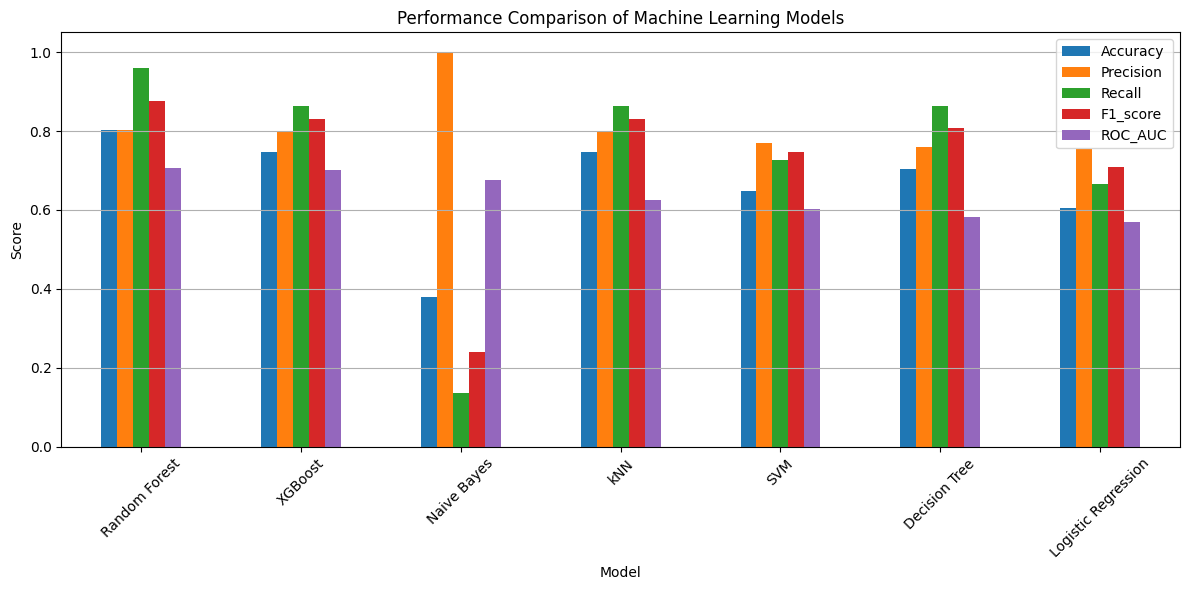

In [238]:
results_df_plot = results_df.set_index("Model")
results_df_plot[["Accuracy","Precision","Recall","F1_score","ROC_AUC"]].plot(
    kind="bar",
    figsize=(12,6)
)
plt.ylabel("Score")
plt.title("Performance Comparison of Machine Learning Models")
plt.xticks(rotation=45)
plt.ylim(0,1.05)
plt.grid(axis="y")
plt.tight_layout()
plt.show()

**Figure 2. ROC Curves**

In [239]:
# Modify the training loop slightly to save probabilities.

roc_results = {}
results = []
for name, model in models.items():
    clf = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    try:
        y_prob = clf.predict_proba(X_test)[:,1]
        auc = roc_auc_score(y_test,y_prob)
        roc_results[name] = y_prob
    except:
        auc = np.nan
    results.append({
        "Model":name,
        "Accuracy":accuracy_score(y_test,y_pred),
        "Precision":precision_score(y_test,y_pred),
        "Recall":recall_score(y_test,y_pred),
        "F1_score":f1_score(y_test,y_pred),
        "ROC_AUC":auc
    })

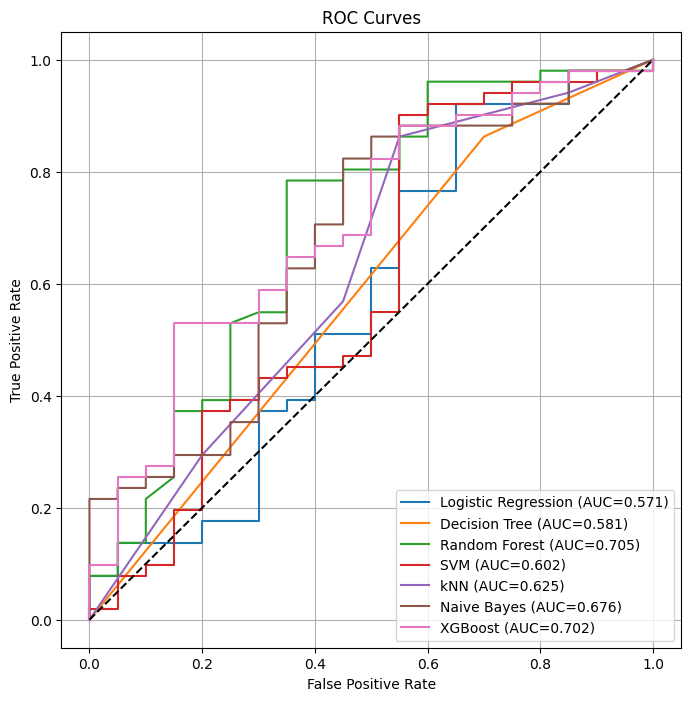

In [240]:
# plot ROC curves

from sklearn.metrics import roc_curve
plt.figure(figsize=(8,8))
for name,y_prob in roc_results.items():
    fpr,tpr,_ = roc_curve(y_test,y_prob)
    auc = roc_auc_score(y_test,y_prob)
    plt.plot(fpr,tpr,label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.grid()
plt.show()

**Figure 3. Confusion Matrix**

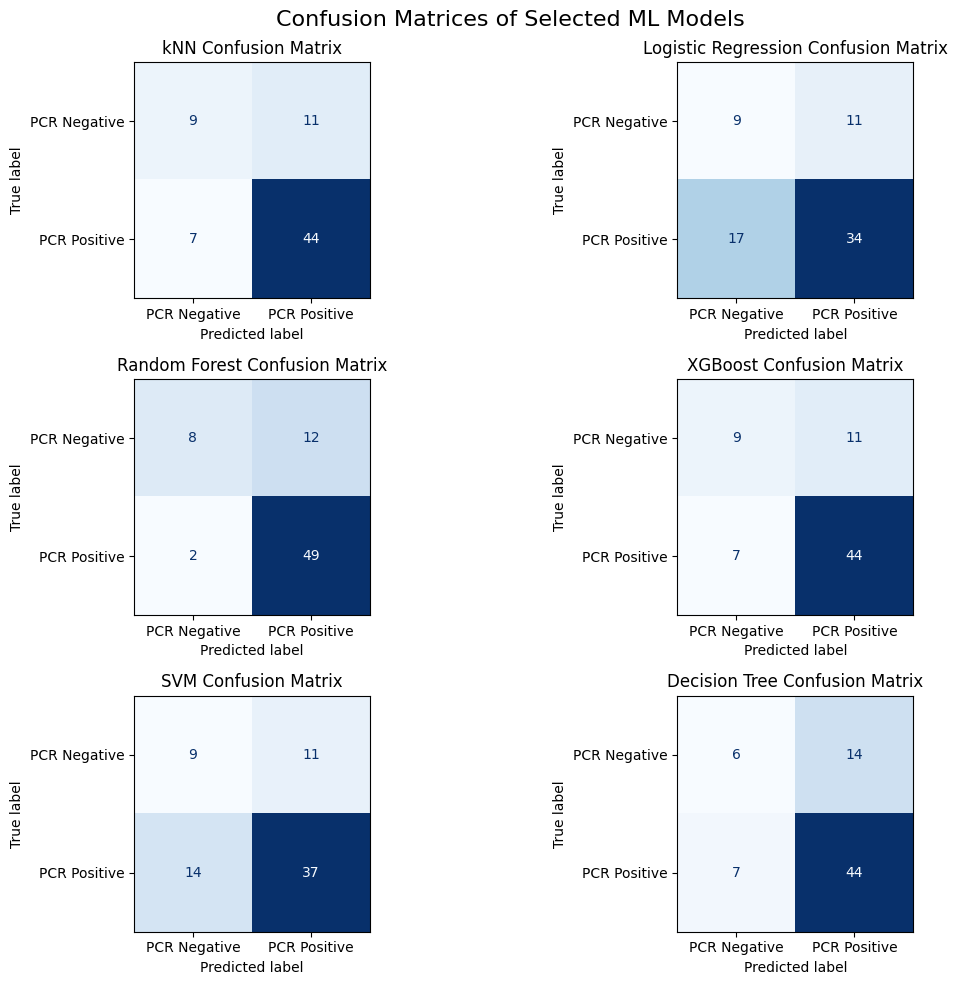

In [241]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models_cm = {
    "kNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ),

    "SVM": SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
    )
}

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.ravel()

for ax, (name, model) in zip(axes, models_cm.items()):

    clf = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    clf.fit(X_train, y_train)

    ConfusionMatrixDisplay.from_estimator(
        clf,
        X_test,
        y_test,
        display_labels=["PCR Negative", "PCR Positive"],
        cmap="Blues",
        ax=ax,
        colorbar=False
    )

    ax.set_title(f"{name} Confusion Matrix")

plt.suptitle("Confusion Matrices of Selected ML Models", fontsize=16)
plt.tight_layout()
plt.show()

**Figure 4. Precision-Recall Curves**

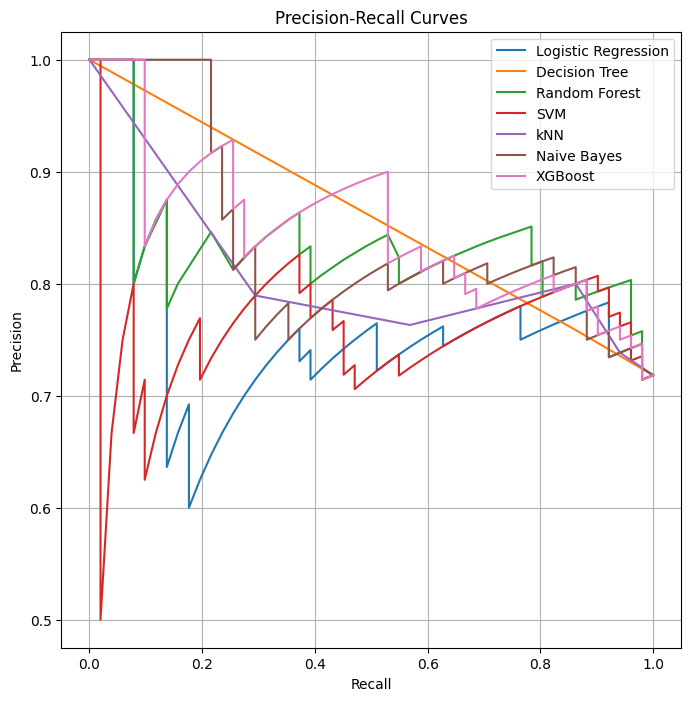

In [242]:
from sklearn.metrics import precision_recall_curve
plt.figure(figsize=(8,8))
for name,y_prob in roc_results.items():
    precision,recall,_ = precision_recall_curve(
        y_test,
        y_prob
    )
    plt.plot(recall,precision,label=name)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves")
plt.legend()
plt.grid()
plt.show()

**Figure 5. Heatmap of Metrics**

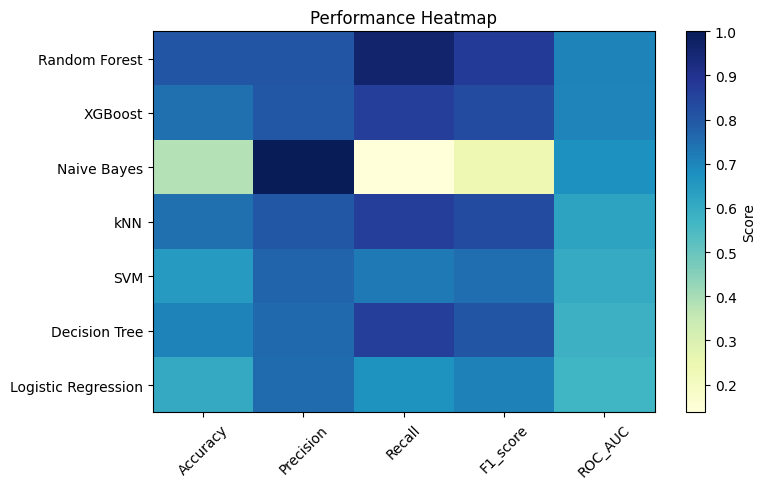

In [243]:
import matplotlib.pyplot as plt
metrics = results_df.set_index("Model")
plt.figure(figsize=(8,5))
plt.imshow(metrics,cmap="YlGnBu",aspect="auto")
plt.colorbar(label="Score")
plt.xticks(range(len(metrics.columns)),metrics.columns,rotation=45)
plt.yticks(range(len(metrics.index)),metrics.index)
plt.title("Performance Heatmap")
plt.tight_layout()
plt.show()

**Figure 6. Feature Importance**


kNN


,Feature_cleaned,Feature_original,Importance,SD
13,platelet_10_9_l,Platelet (10^9/L),0.120025,0.040633
15,nlr,NLR,0.047451,0.010791
5,temperature_c,Temperature (c),0.046471,0.017229
9,wbc_count_10_9_l,WBC_count (10^9/L),0.042917,0.022998
16,alt_iu_l,ALT (IU/L),0.039485,0.016958
14,thrombocytopenia_grade,Thrombocytopenia Grade,0.032304,0.028401
28,bodyache,bodyache,0.019314,0.014769
38,egfr,eGFR,0.018088,0.024874
17,ast_iu_l,AST (IU/L),0.017623,0.012640
10,lymph_count,Lymph_count (%),0.016789,0.029198



Random Forest


,Feature_cleaned,Feature_original,Importance,SD
13,platelet_10_9_l,Platelet (10^9/L),0.038358,0.045240
9,wbc_count_10_9_l,WBC_count (10^9/L),0.023333,0.019410
15,nlr,NLR,0.017377,0.009768
11,neut_count,Neut_count (%),0.017132,0.009256
10,lymph_count,Lymph_count (%),0.016863,0.007060
6,respiratory_rate,Respiratory rate,0.010490,0.003617
5,temperature_c,Temperature (c),0.009338,0.012581
16,alt_iu_l,ALT (IU/L),0.004975,0.009323
4,pulse,Pulse,0.004314,0.007094
23,diabetes,Diabetes,0.003995,0.001299



Logistic Regression


...

,Feature_cleaned,Feature_original,Importance,SD
13,platelet_10_9_l,Platelet (10^9/L),0.099657,0.055605
9,wbc_count_10_9_l,WBC_count (10^9/L),0.037255,0.022957
10,lymph_count,Lymph_count (%),0.016275,0.010506
16,alt_iu_l,ALT (IU/L),0.015833,0.011375
11,neut_count,Neut_count (%),0.014265,0.006007
15,nlr,NLR,0.010784,0.008019
5,temperature_c,Temperature (c),0.008431,0.013576
19,creatinine_mg_dl,Creatinine (mg/dl),0.003333,0.016587
30,abdominal_pain,abdominal pain,0.001569,0.000784
27,nausea_vomiting,Nausea & vomiting,0.001422,0.003092



SVM


,Feature_cleaned,Feature_original,Importance,SD
13,platelet_10_9_l,Platelet (10^9/L),0.069118,0.040480
5,temperature_c,Temperature (c),0.043333,0.015713
9,wbc_count_10_9_l,WBC_count (10^9/L),0.026422,0.014873
14,thrombocytopenia_grade,Thrombocytopenia Grade,0.018039,0.020340
19,creatinine_mg_dl,Creatinine (mg/dl),0.010441,0.012321
15,nlr,NLR,0.008775,0.009339
26,headache,Headache,0.004118,0.003488
18,bun_mg_dl,BUN (mg/dl),0.003382,0.018796
16,alt_iu_l,ALT (IU/L),0.003088,0.015462
38,egfr,eGFR,0.002402,0.023867



Decision Tree


,Feature_cleaned,Feature_original,Importance,SD
13,platelet_10_9_l,Platelet (10^9/L),0.078725,0.035394
11,neut_count,Neut_count (%),0.037966,0.012600
18,bun_mg_dl,BUN (mg/dl),0.027770,0.010683
2,systolic_blood_pressure,Systolic Blood Pressure,0.026593,0.020507
9,wbc_count_10_9_l,WBC_count (10^9/L),0.025490,0.009505
12,hemoglobin_g_dl,Hemoglobin (g/dl),0.012843,0.021288
14,thrombocytopenia_grade,Thrombocytopenia Grade,0.010294,0.007889
19,creatinine_mg_dl,Creatinine (mg/dl),0.010294,0.008476
1,days_of_fever,Days of Fever,0.008922,0.022463
15,nlr,NLR,0.008358,0.017302


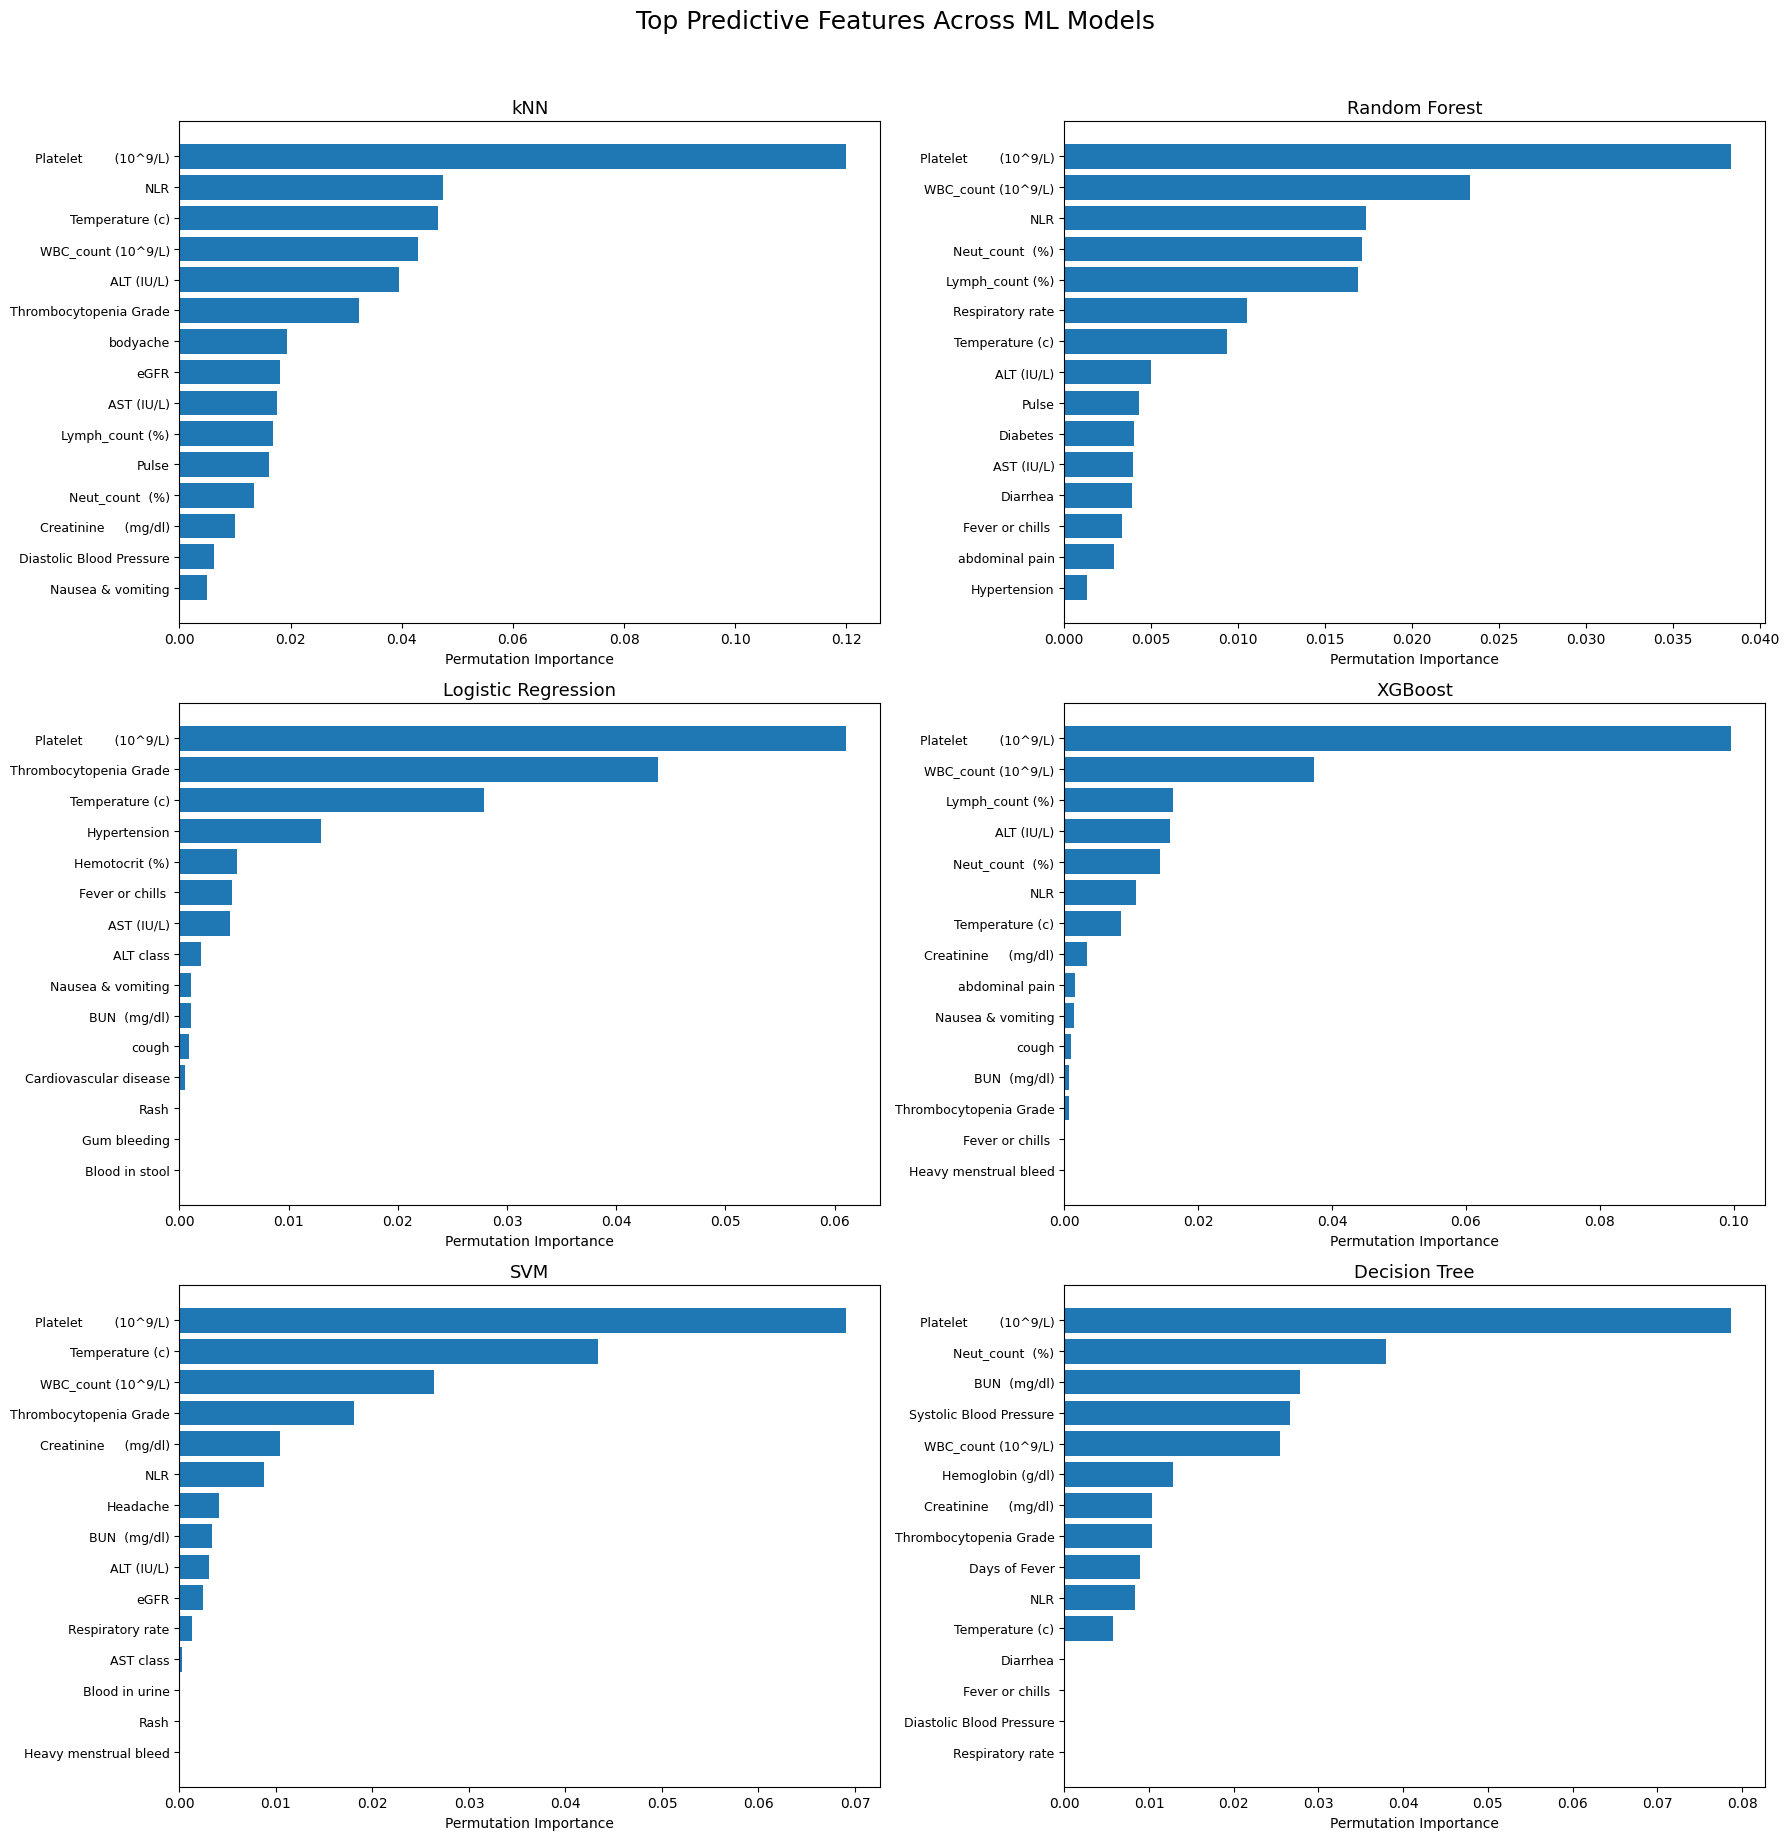

In [245]:
from sklearn.inspection import permutation_importance

# Step 1: Create mapping from cleaned column names back to original Excel column names
cleaned_columns_from_original = (
    pd.Series(original_columns)
    .astype(str)
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", "_", regex=True)
    .str.replace(r"[^\w]", "_", regex=True)
    .str.replace(r"_+", "_", regex=True)
    .str.strip("_")
    .tolist()
)
clean_to_original = dict(zip(cleaned_columns_from_original, original_columns))

# Step 2: Define selected models
models_importance = {
    "kNN": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    ),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ),

    "SVM": SVC(
        probability=True,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    )
}

# Step 3: Calculate permutation importance

importance_tables = {}
for name, model in models_importance.items():
    clf = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    clf.fit(X_train, y_train)
    result = permutation_importance(
        clf,
        X_test,
        y_test,
        scoring="roc_auc",
        n_repeats=20,
        random_state=42
    )

    importance_df = pd.DataFrame({
        "Feature_cleaned": X_test.columns,
        "Feature_original": [
            clean_to_original.get(col, col) for col in X_test.columns
        ],
        "Importance": result.importances_mean,
        "SD": result.importances_std
    }).sort_values("Importance", ascending=False)

    importance_tables[name] = importance_df
    print("\n" + "="*70)
    print(name)
    print("="*70)
    display(importance_df.head(20))

# Step 4: Plot top 15 features for each model in 3 x 2 format
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
axes = axes.ravel()
for ax, (name, importance_df) in zip(axes, importance_tables.items()):
    top = importance_df.head(15).sort_values("Importance")
    ax.barh(
        top["Feature_original"],
        top["Importance"]
    )
    ax.set_title(name, fontsize=13)
    ax.set_xlabel("Permutation Importance")
    ax.tick_params(axis="y", labelsize=9)
plt.suptitle(
    "Top Predictive Features Across ML Models",
    fontsize=18,
    y=1.02
)
plt.tight_layout()
plt.show()

**Step 17 — Internal Cross-validation**

In this step the full dataset of 283 patients is divided into 5 folds.
Fold 1 ≈ 56–57 patients

1. Fold 2 ≈ 56–57 patients
2. Fold 3 ≈ 56–57 patients
3. Fold 4 ≈ 56–57 patients
4. Fold 5 ≈ 56–57 patients

Then the model is trained and tested five times:

* Round 1: Train on folds 2–5, test on fold 1
* Round 2: Train on folds 1,3,4,5, test on fold 2
* Round 3: Train on folds 1,2,4,5, test on fold 3
* Round 4: Train on folds 1,2,3,5, test on fold 4
* Round 5: Train on folds 1–4, test on fold 5

Each round uses about:

* 80% training data
* 20% validation data

We did not get a new dataset for cross-validation. Cross-validation used the same final cleaned dataset: X_fixed and y

# Important Note:
Because the dataset was relatively small, internal five-fold stratified cross-validation was used to obtain a more reliable estimate of model performance and stability than a single train-test split. However, external validation on an independent dataset is preferable and remains necessary to confirm generalizability, because such a dataset would include patients that the model has never encountered during training or internal validation.

# Another Important Note:
We did the first 75:25 split mainly for practical visualization and detailed metrics. A single held-out test set makes it easy to generate confusion matrices, ROC curves, precision, recall, F1-score, and model-wise comparison plots. It gives a simple, intuitive first look at model behavior.

But for final model ranking, cross-validation is more reliable, especially because our dataset is small. That is why our final conclusion should be based mainly on cross-validation results, not only on the single 75:25 split.

In [246]:
cv = StratifiedKFold(
    n_splits=5, # 4 folds are used for training = 80% and 1 fold for validation = 20%
    shuffle=True,
    random_state=42
)
cv_results = []
cv_scores = {}          # <-- Store every fold score

for name, model in models.items():
    clf = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    scores = cross_val_score(
        clf,
        X_fixed,
        y,
        cv=cv,
        scoring="roc_auc"
    )
    cv_scores[name] = scores

    cv_results.append({
        "Model": name,
        "Mean_ROC_AUC": scores.mean(),
        "SD_ROC_AUC": scores.std()
    })

cv_results_df = (
    pd.DataFrame(cv_results)
      .sort_values("Mean_ROC_AUC", ascending=False)
)

cv_results_df

,Model,Mean_ROC_AUC,SD_ROC_AUC
2,Random Forest,0.687919,0.099049
6,XGBoost,0.684040,0.103315
5,Naive Bayes,0.663853,0.067081
0,Logistic Regression,0.659177,0.086808
3,SVM,0.649093,0.103455
4,kNN,0.602591,0.116781
1,Decision Tree,0.540518,0.057711


# **Interpretation:**
**ROC-AUC measures how well a model separates the two outcome classes, in this case DENV PCR-positive and DENV PCR-negative patients. A ROC-AUC of 0.5 indicates performance no better than random guessing, whereas a ROC-AUC of 1.0 indicates perfect discrimination.**

After performing five-fold stratified cross-validation, the machine-learning models showed moderate discriminatory performance for predicting DENV PCR positivity from routine clinical and laboratory variables. Among the evaluated classifiers, Random Forest achieved the highest mean ROC-AUC of 0.688 ± 0.099, followed very closely by XGBoost with 0.684 ± 0.103. These results indicate that ensemble-based models were able to capture some clinically meaningful patterns associated with PCR positivity. However, the ROC-AUC values remained below 0.70, suggesting that the predictive signal is present but limited.

The close performance of Random Forest and XGBoost suggests that nonlinear interactions among clinical and laboratory variables may contribute to PCR-status prediction. However, both models also showed relatively high standard deviations across folds, indicating variability in model performance depending on the training and validation split. This instability is likely related to the modest sample size, class imbalance between PCR-positive and PCR-negative cases, and overlap in clinical presentation between dengue and dengue-like illness. Therefore, although Random Forest performed best overall, its performance should be interpreted cautiously.

Naive Bayes achieved a mean ROC-AUC of 0.664 ± 0.067, showing moderate but lower discrimination compared with Random Forest and XGBoost. Interestingly, its lower standard deviation suggests more stable performance across folds, but its assumptions of feature independence may be unrealistic for clinical datasets where symptoms, vital signs, hematological markers, and biochemical variables are biologically interrelated. Logistic Regression achieved a ROC-AUC of 0.659 ± 0.087, indicating that a linear model could detect some signal but was less effective than the tree-based ensemble models. This suggests that the relationship between clinical/laboratory predictors and PCR positivity may not be purely linear.

SVM showed slightly weaker performance with a ROC-AUC of 0.649 ± 0.103, while kNN performed poorly with 0.603 ± 0.117 and showed high variability across folds. The poor stability of kNN suggests that patient-level similarity in this feature space is not strong enough for reliable classification, likely because PCR-positive and PCR-negative patients have overlapping clinical profiles. Decision Tree showed the weakest performance, with a ROC-AUC of 0.541 ± 0.058, close to random classification. This indicates that a single tree was unable to generalize well and may be too unstable or simplistic for this dataset.

Overall, these results suggest that routine clinical and laboratory variables contain a measurable but moderate diagnostic signal for identifying DENV PCR-positive patients. Random Forest can be considered the best-performing model in this corrected analysis, with XGBoost as a close alternative. However, the overall performance remains insufficient for standalone diagnosis. The model should therefore be interpreted as an exploratory diagnostic-support or triage tool, potentially useful for prioritizing molecular testing, but not as a replacement for qRT-PCR confirmation.

**Figure 7. Mean ROC-AUC ± Standard Deviation**

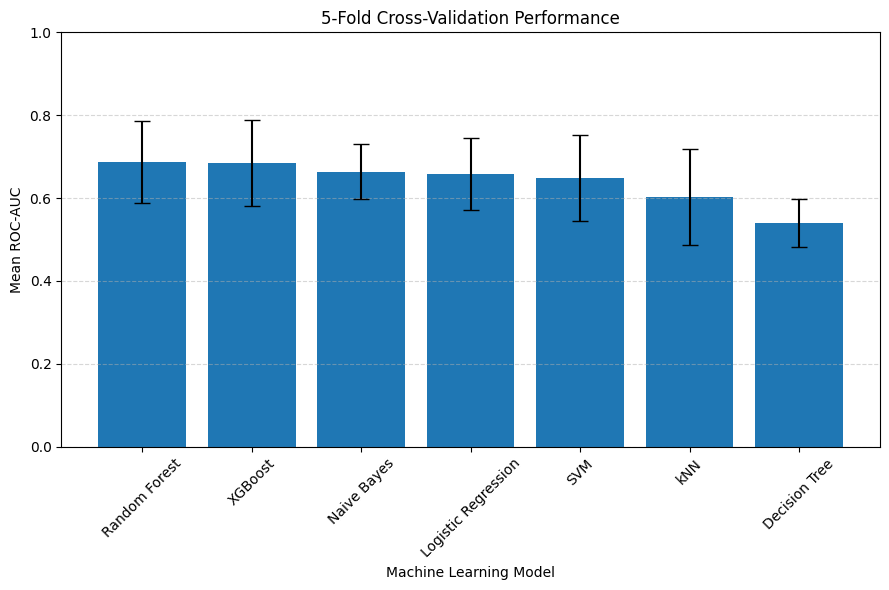

In [247]:
plt.figure(figsize=(9,6))

plt.bar(
    cv_results_df["Model"],
    cv_results_df["Mean_ROC_AUC"],
    yerr=cv_results_df["SD_ROC_AUC"],
    capsize=6
)

plt.ylabel("Mean ROC-AUC")
plt.xlabel("Machine Learning Model")
plt.title("5-Fold Cross-Validation Performance")

plt.ylim(0,1)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

**Figure 8. ROC-AUC Boxplot Across Folds**

Interpretation:

* Smaller box = more stable model.
* Higher median = better model.
* Smaller whiskers = lower variability.

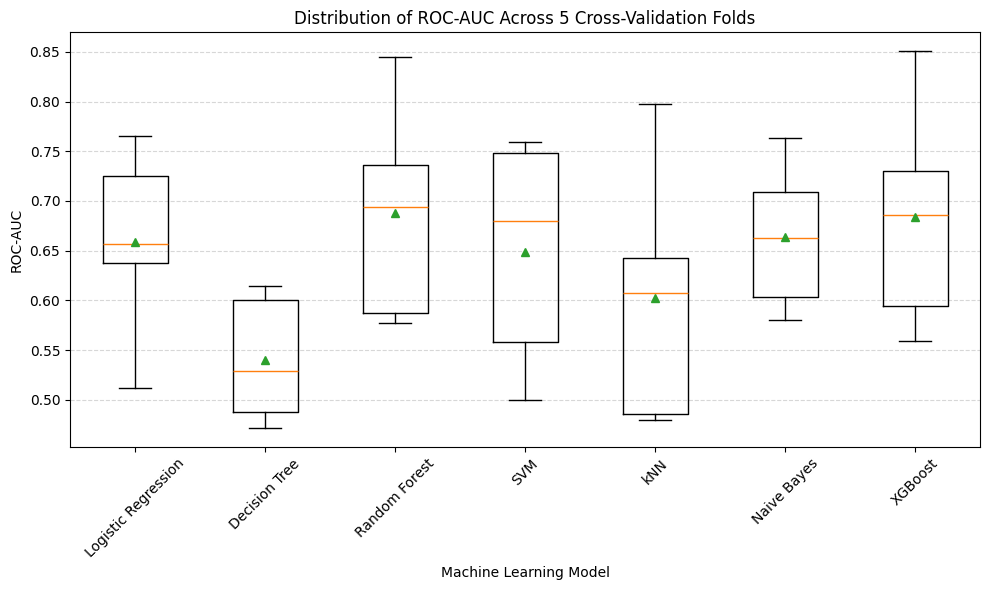

In [248]:
# This shows how stable each model is across the five folds.

plt.figure(figsize=(10,6))
plt.boxplot(
    [cv_scores[m] for m in cv_scores.keys()],
    tick_labels=cv_scores.keys(),
    showmeans=True
)
plt.ylabel("ROC-AUC")
plt.xlabel("Machine Learning Model")
plt.title("Distribution of ROC-AUC Across 5 Cross-Validation Folds")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Figure 9. Model Stability Comparison**

It tells:

* which model has the highest ROC-AUC;
* which model has the smallest standard deviation;
* the trade-off between performance and stability.

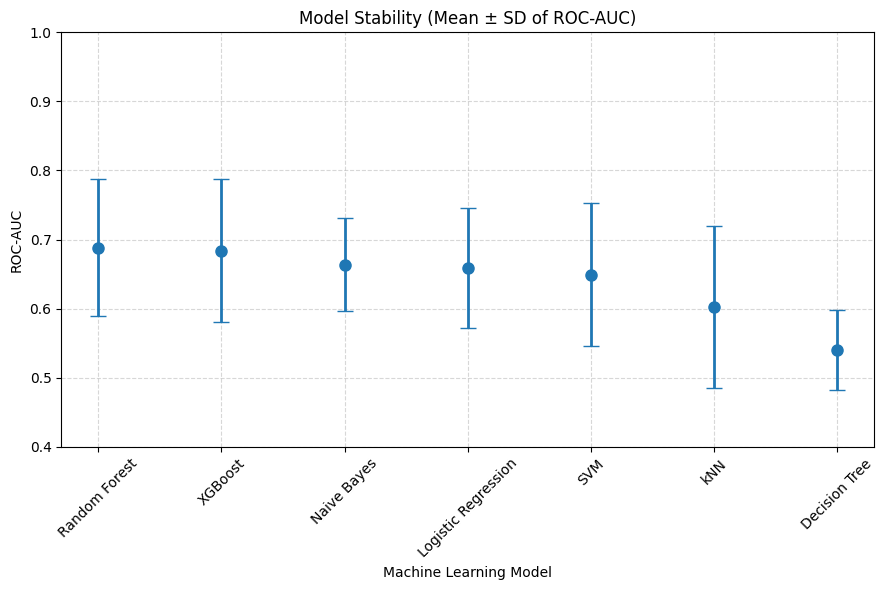

In [249]:
plt.figure(figsize=(9,6))

plt.errorbar(
    cv_results_df["Model"],
    cv_results_df["Mean_ROC_AUC"],
    yerr=cv_results_df["SD_ROC_AUC"],
    fmt="o",
    capsize=6,
    linewidth=2,
    markersize=8
)
plt.ylabel("ROC-AUC")
plt.xlabel("Machine Learning Model")
plt.title("Model Stability (Mean ± SD of ROC-AUC)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.xticks(rotation=45)
plt.ylim(0.4,1.0)
plt.tight_layout()
plt.show()

**Figure 10. Fold-wise ROC-AUC**

This highlights whether a model performs consistently across folds or has unusually high or low performance in specific folds.

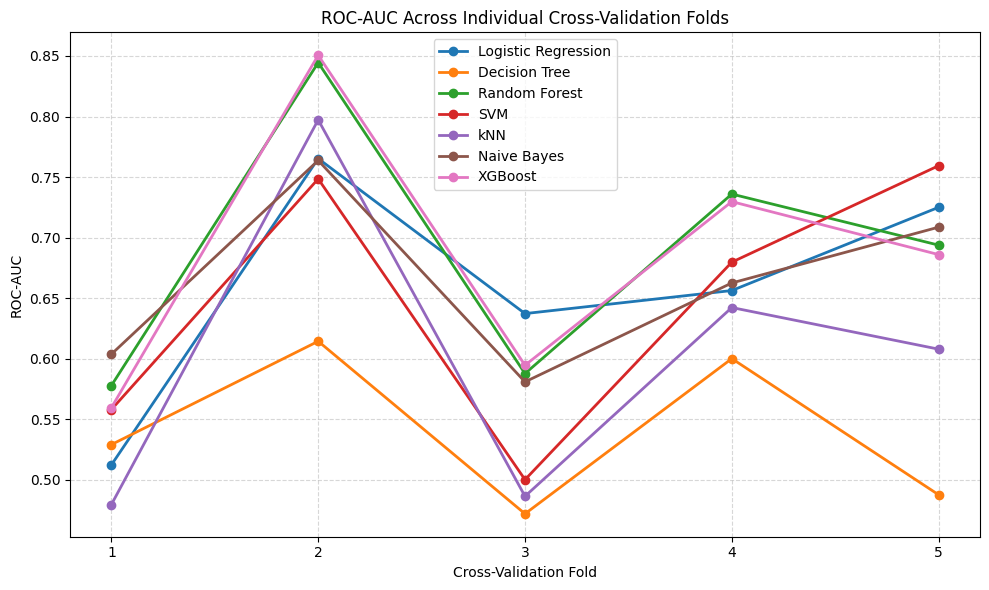

In [250]:
cv_plot = pd.DataFrame(cv_scores)

plt.figure(figsize=(10,6))
for model in cv_plot.columns:
    plt.plot(
        range(1,6),
        cv_plot[model],
        marker="o",
        linewidth=2,
        label=model
    )
plt.xlabel("Cross-Validation Fold")
plt.ylabel("ROC-AUC")
plt.title("ROC-AUC Across Individual Cross-Validation Folds")
plt.xticks(range(1,6))
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

**Figure 11. Ranked Mean ROC-AUC**

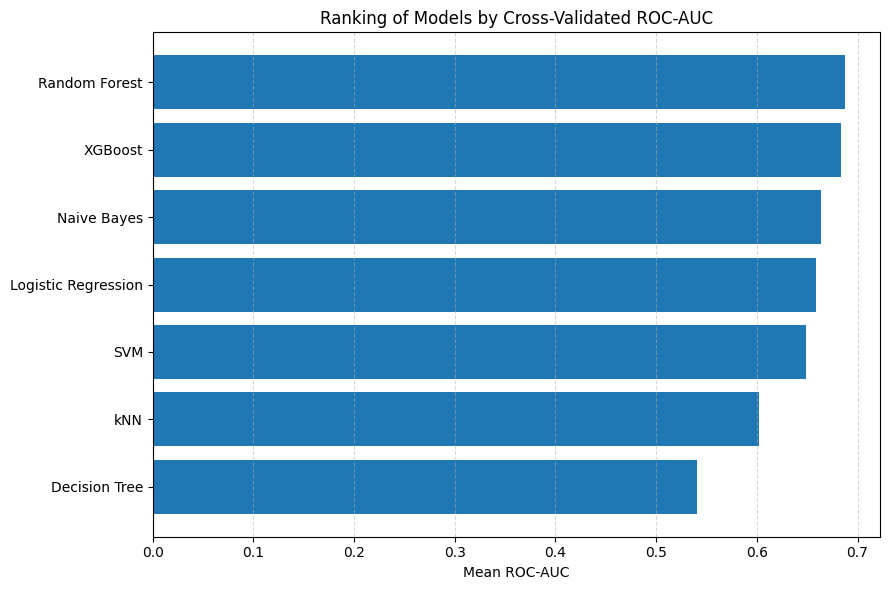

In [251]:
cv_results_df = cv_results_df.sort_values(
    "Mean_ROC_AUC",
    ascending=True
)
plt.figure(figsize=(9,6))
plt.barh(
    cv_results_df["Model"],
    cv_results_df["Mean_ROC_AUC"]
)
plt.xlabel("Mean ROC-AUC")
plt.title("Ranking of Models by Cross-Validated ROC-AUC")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Discussion of cross-validation performance

The five-fold stratified cross-validation results show that the machine-learning models achieved moderate discriminatory performance for predicting DENV PCR positivity using the selected clinical and laboratory variables. The best-performing model was Random Forest, followed very closely by XGBoost. This is visible in the ranking plot, where Random Forest had the highest mean ROC-AUC, and XGBoost was only slightly lower. This suggests that tree-based ensemble models were able to capture some nonlinear or interaction-based patterns in the clinical/laboratory data.

The overall ROC-AUC values, however, remained in the moderate range. Most models clustered between approximately 0.60 and 0.69, indicating that the available predictors contain a real but limited diagnostic signal. Random Forest and XGBoost performed better than Logistic Regression and SVM, suggesting that the relationship between routine clinical/laboratory variables and PCR positivity may not be purely linear. However, the difference between the top models was small, so the superiority of Random Forest should be interpreted cautiously.

The error-bar and model-stability plots show that Random Forest and XGBoost had the highest mean ROC-AUC values but also relatively large standard deviations. This means their performance varied across folds. In the fold-wise ROC-AUC plot, both models performed strongly in some folds, especially fold 2, but dropped in fold 3. This variability suggests that model performance is sensitive to how patients are split across training and validation folds. This is likely due to the modest sample size, class imbalance, and overlap between PCR-positive dengue and PCR-negative dengue-like illness cases.

Naive Bayes showed moderate performance and appeared somewhat more stable than some other models, but it did not outperform the ensemble models. Logistic Regression and SVM also showed moderate performance, but their ROC-AUC values were slightly lower than Random Forest and XGBoost. kNN showed weaker and more variable performance, suggesting that simple distance-based similarity between patients is not sufficient to reliably separate PCR-positive from PCR-negative cases in this feature space. Decision Tree showed the weakest performance, with ROC-AUC close to random classification, indicating that a single tree is too unstable or too simple for this dataset.

The boxplot further confirms that there is no perfect or highly stable classifier. The inter-fold distributions overlap substantially across models, especially among Random Forest, XGBoost, Naive Bayes, Logistic Regression, and SVM. This means that although Random Forest ranked first, the overall classification task remains challenging. The clinical and laboratory profiles of PCR-positive and PCR-negative patients likely overlap substantially, which limits the maximum achievable performance using routine variables alone.

Overall, these cross-validation results indicate that routine clinical and laboratory variables can provide supportive diagnostic information for DENV PCR positivity, but they are not strong enough for standalone diagnosis. Random Forest can be reported as the best-performing model, with XGBoost as a close alternative. However, because the best ROC-AUC remains below 0.70 and the fold-to-fold variability is noticeable, the model should be interpreted as an exploratory diagnostic-support or triage tool, not as a replacement for qRT-PCR confirmation.

**Figure 12. PCA analysis: PCR-positive vs PCR-negative**

,Principal_Component,Explained_Variance_Ratio,Explained_Variance_Percent
0,PC1,0.145894,14.589355
1,PC2,0.111548,11.154792
2,PC3,0.096790,9.679026
3,PC4,0.072203,7.220304


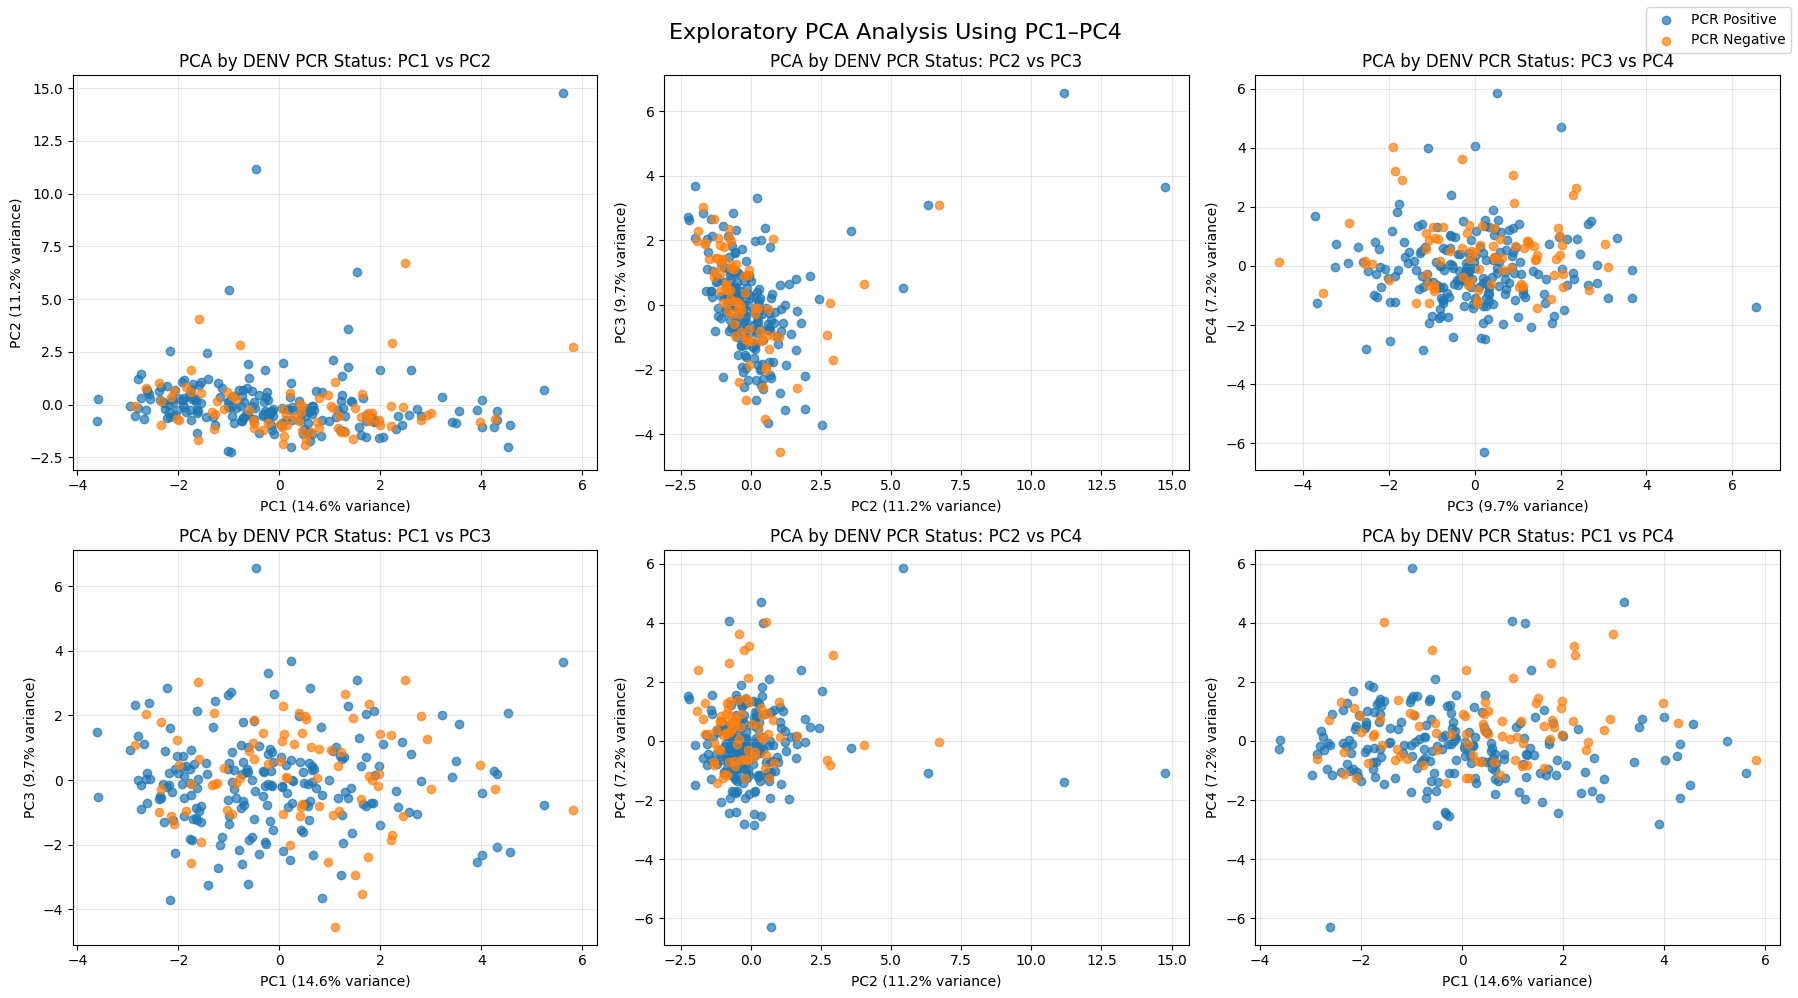

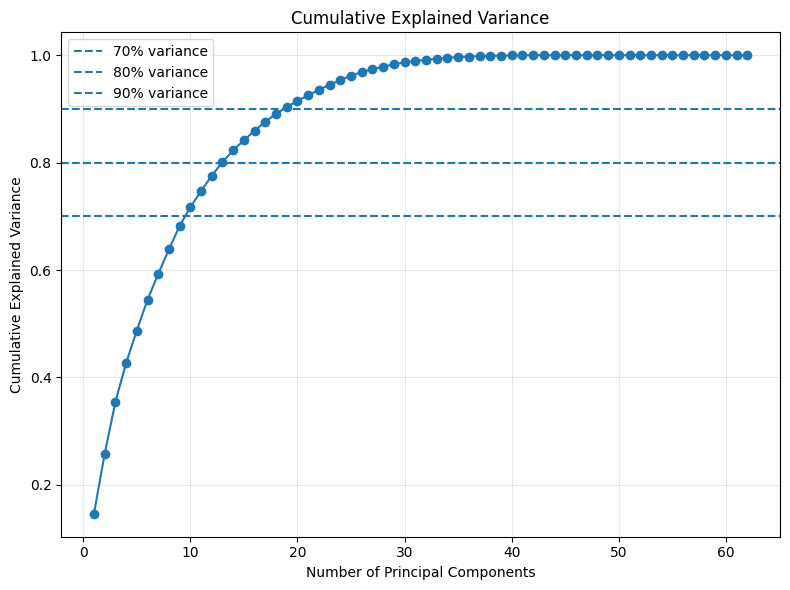

In [252]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# PCA-only dataset: remove study-design variables
# ---------------------------------------------------------

X_pca_clinical = X_fixed.drop(columns=["year", "aim"], errors="ignore")

# Recreate numeric and categorical features for PCA dataset
numeric_features_pca = X_pca_clinical.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features_pca = X_pca_clinical.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

# Build PCA-specific preprocessor
numeric_transformer_pca = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_pca = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor_pca = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_pca, numeric_features_pca),
        ("cat", categorical_transformer_pca, categorical_features_pca)
    ],
    sparse_threshold=0
)

# Transform features
X_processed = preprocessor_pca.fit_transform(X_pca_clinical)

# ---------------------------------------------------------
# PCA for PC1–PC4
# ---------------------------------------------------------

pca_4d = PCA(n_components=4, random_state=42)
X_pca_4d = pca_4d.fit_transform(X_processed)

# Full PCA for cumulative explained variance
pca_full = PCA()
pca_full.fit(X_processed)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# PCA dataframe with PC1–PC4
pca_df = pd.DataFrame({
    "PC1": X_pca_4d[:, 0],
    "PC2": X_pca_4d[:, 1],
    "PC3": X_pca_4d[:, 2],
    "PC4": X_pca_4d[:, 3],
    "PCR_status": y.map({
        0: "PCR Negative",
        1: "PCR Positive"
    })
})

# Display explained variance for PC1–PC4
variance_df = pd.DataFrame({
    "Principal_Component": ["PC1", "PC2", "PC3", "PC4"],
    "Explained_Variance_Ratio": pca_4d.explained_variance_ratio_,
    "Explained_Variance_Percent": pca_4d.explained_variance_ratio_ * 100
})

display(variance_df)

# ---------------------------------------------------------
# PCA scatter plots using PC1–PC4
# ---------------------------------------------------------

pc_pairs = [
    ("PC1", "PC2"),
    ("PC2", "PC3"),
    ("PC3", "PC4"),
    ("PC1", "PC3"),
    ("PC2", "PC4"),
    ("PC1", "PC4")
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for ax, (pc_x, pc_y) in zip(axes, pc_pairs):

    for status in pca_df["PCR_status"].unique():
        subset = pca_df[pca_df["PCR_status"] == status]

        ax.scatter(
            subset[pc_x],
            subset[pc_y],
            label=status,
            alpha=0.7
        )

    pc_x_index = int(pc_x.replace("PC", "")) - 1
    pc_y_index = int(pc_y.replace("PC", "")) - 1

    ax.set_xlabel(
        f"{pc_x} ({pca_4d.explained_variance_ratio_[pc_x_index]*100:.1f}% variance)"
    )

    ax.set_ylabel(
        f"{pc_y} ({pca_4d.explained_variance_ratio_[pc_y_index]*100:.1f}% variance)"
    )

    ax.set_title(f"PCA by DENV PCR Status: {pc_x} vs {pc_y}")
    ax.grid(alpha=0.3)

# Add one shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper right"
)

plt.suptitle(
    "Exploratory PCA Analysis Using PC1–PC4",
    fontsize=16
)

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Cumulative explained variance plot
# ---------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.axhline(y=0.70, linestyle="--", label="70% variance")
plt.axhline(y=0.80, linestyle="--", label="80% variance")
plt.axhline(y=0.90, linestyle="--", label="90% variance")

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Discussion of PCA explained variance and PC1–PC4 plots

The PCA results show that the first four principal components explain a total of approximately 42.6% of the overall variance in the clinical and laboratory dataset. Specifically, PC1 explains 14.6%, PC2 explains 11.2%, PC3 explains 9.7%, and PC4 explains 7.2% of the variance. This indicates that no single principal component dominates the dataset. Instead, the clinical variation is distributed across multiple dimensions, suggesting that dengue PCR-positive and PCR-negative patients differ through a combination of hematological, biochemical, renal, and vital-sign variables rather than through one strong isolated feature.

The PC1 vs PC2 plot shows substantial overlap between PCR-positive and PCR-negative patients. Although a few outliers are visible, most patients cluster together in the central region. This means that the first two principal components, which together explain about 25.7% of the total variance, do not clearly separate DENV PCR-positive from PCR-negative cases. Therefore, the major sources of variation in the dataset are not exclusively driven by PCR status.

The additional PCA projections using PC2 vs PC3, PC3 vs PC4, PC1 vs PC3, PC2 vs PC4, and PC1 vs PC4 show the same pattern: PCR-positive and PCR-negative patients remain highly overlapping across all component combinations. This suggests that even when including PC3 and PC4, the clinical and laboratory profile does not form clearly distinct natural clusters according to PCR status. The lack of separation supports the cross-validation results, where the best models achieved only moderate ROC-AUC values.

Biologically, this is reasonable. Dengue PCR-positive and PCR-negative patients can share many similar clinical features, such as fever, bodyache, thrombocytopenia, altered leukocyte counts, and liver-enzyme changes. Many dengue-like illnesses can produce overlapping symptoms and laboratory abnormalities. Therefore, routine clinical and laboratory variables may contain useful diagnostic signal, but that signal is distributed and partially overlapping rather than sharply separated.

Overall, PCA supports the conclusion that the dataset contains meaningful clinical structure, but that structure is not sufficient to visually or mathematically separate PCR-positive and PCR-negative patients in a low-dimensional unsupervised space. This explains why supervised ML models such as Random Forest and XGBoost achieved moderate performance but did not reach high diagnostic accuracy. The PCA findings therefore reinforce the interpretation that these models may be useful for exploratory diagnostic support or prioritization of molecular testing, but they cannot replace qRT-PCR confirmation.

In [253]:
from sklearn.decomposition import PCA

# ---------------------------------------------------------
# PCA with 4 components
# ---------------------------------------------------------

X_processed_pca = preprocessor_pca.fit_transform(X_fixed)

pca_4d = PCA(n_components=4)

X_pca_4d = pca_4d.fit_transform(X_processed_pca)

print("Explained variance ratio:")
print(pca_4d.explained_variance_ratio_)

print("Explained variance percentage:")
print(pca_4d.explained_variance_ratio_ * 100)

Explained variance ratio:
[0.14589355 0.11154792 0.09679026 0.07220304]
Explained variance percentage:
[14.58935452 11.15479192  9.67902622  7.22030449]


In [254]:
# ---------------------------------------------------------
# PCA loading table with original Excel column names: PC1–PC4
# ---------------------------------------------------------

feature_names_pca = preprocessor_pca.get_feature_names_out()

loadings_df = pd.DataFrame(
    pca_4d.components_.T,
    columns=["PC1_loading", "PC2_loading", "PC3_loading", "PC4_loading"],
    index=feature_names_pca
)

# Convert preprocessed feature names back to cleaned/raw feature names
def extract_original_feature_name(feature_name):
    feature_name = feature_name.replace("num__", "").replace("cat__", "")

    for col in X.columns:
        if feature_name == col or feature_name.startswith(col + "_"):
            return col

    return feature_name

loadings_df["Feature_cleaned"] = [
    extract_original_feature_name(f) for f in loadings_df.index
]

loadings_df["Feature_original"] = [
    clean_to_original.get(col, col) for col in loadings_df["Feature_cleaned"]
]

# Absolute loading values
loadings_df["PC1_abs"] = loadings_df["PC1_loading"].abs()
loadings_df["PC2_abs"] = loadings_df["PC2_loading"].abs()
loadings_df["PC3_abs"] = loadings_df["PC3_loading"].abs()
loadings_df["PC4_abs"] = loadings_df["PC4_loading"].abs()

# Keep only useful columns
loadings_df = loadings_df[
    [
        "Feature_original",
        "PC1_loading",
        "PC2_loading",
        "PC3_loading",
        "PC4_loading",
        "PC1_abs",
        "PC2_abs",
        "PC3_abs",
        "PC4_abs"
    ]
]

print("Top contributors to PC1:")
display(
    loadings_df
    .sort_values("PC1_abs", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

print("Top contributors to PC2:")
display(
    loadings_df
    .sort_values("PC2_abs", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

print("Top contributors to PC3:")
display(
    loadings_df
    .sort_values("PC3_abs", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

print("Top contributors to PC4:")
display(
    loadings_df
    .sort_values("PC4_abs", ascending=False)
    .head(15)
    .reset_index(drop=True)
)

Top contributors to PC1:


,Feature_original,PC1_loading,PC2_loading,PC3_loading,PC4_loading,PC1_abs,PC2_abs,PC3_abs,PC4_abs
0,Neut_count (%),0.504389,-0.050218,0.055756,-0.160617,0.504389,0.050218,0.055756,0.160617
1,Lymph_count (%),-0.480357,0.079418,-0.061604,0.215894,0.480357,0.079418,0.061604,0.215894
2,NLR,0.450383,-0.023243,0.018120,-0.153183,0.450383,0.023243,0.018120,0.153183
3,Platelet (10^9/L),0.335115,-0.160517,0.104577,0.242912,0.335115,0.160517,0.104577,0.242912
4,WBC_count (10^9/L),0.149837,0.095524,0.158302,0.339907,0.149837,0.095524,0.158302,0.339907
5,Thrombocytopenia Grade,0.147621,-0.064548,0.063820,0.077714,0.147621,0.064548,0.063820,0.077714
6,Respiratory rate,0.143056,-0.065284,0.030475,0.429317,0.143056,0.065284,0.030475,0.429317
7,Hemoglobin (g/dl),-0.137186,-0.236338,0.448860,-0.337829,0.137186,0.236338,0.448860,0.337829
8,Hemotocrit (%),-0.137186,-0.231577,0.490233,-0.210566,0.137186,0.231577,0.490233,0.210566
9,Diastolic Blood Pressure,-0.129821,-0.135970,0.377183,0.265660,0.129821,0.135970,0.377183,0.265660


Top contributors to PC2:


,Feature_original,PC1_loading,PC2_loading,PC3_loading,PC4_loading,PC1_abs,PC2_abs,PC3_abs,PC4_abs
0,AST (IU/L),0.015073,0.475757,0.218876,-0.085873,0.015073,0.475757,0.218876,0.085873
1,ALT (IU/L),0.048780,0.446188,0.191020,-0.050994,0.048780,0.446188,0.191020,0.050994
2,Creatinine (mg/dl),0.111595,0.426247,0.277218,-0.160619,0.111595,0.426247,0.277218,0.160619
3,BUN (mg/dl),0.068644,0.319724,0.134732,0.216913,0.068644,0.319724,0.134732,0.216913
4,Hemoglobin (g/dl),-0.137186,-0.236338,0.448860,-0.337829,0.137186,0.236338,0.448860,0.337829
5,Hemotocrit (%),-0.137186,-0.231577,0.490233,-0.210566,0.137186,0.231577,0.490233,0.210566
6,Days of Fever,-0.098596,0.226019,0.012051,0.104497,0.098596,0.226019,0.012051,0.104497
7,Platelet (10^9/L),0.335115,-0.160517,0.104577,0.242912,0.335115,0.160517,0.104577,0.242912
8,Temperature (c),0.123418,-0.157367,0.024824,-0.070798,0.123418,0.157367,0.024824,0.070798
9,Diastolic Blood Pressure,-0.129821,-0.135970,0.377183,0.265660,0.129821,0.135970,0.377183,0.265660


Top contributors to PC3:


,Feature_original,PC1_loading,PC2_loading,PC3_loading,PC4_loading,PC1_abs,PC2_abs,PC3_abs,PC4_abs
0,Hemotocrit (%),-0.137186,-0.231577,0.490233,-0.210566,0.137186,0.231577,0.490233,0.210566
1,Hemoglobin (g/dl),-0.137186,-0.236338,0.448860,-0.337829,0.137186,0.236338,0.448860,0.337829
2,Systolic Blood Pressure,-0.078734,-0.129354,0.386739,0.243950,0.078734,0.129354,0.386739,0.243950
3,Diastolic Blood Pressure,-0.129821,-0.135970,0.377183,0.265660,0.129821,0.135970,0.377183,0.265660
4,Creatinine (mg/dl),0.111595,0.426247,0.277218,-0.160619,0.111595,0.426247,0.277218,0.160619
5,AST (IU/L),0.015073,0.475757,0.218876,-0.085873,0.015073,0.475757,0.218876,0.085873
6,ALT (IU/L),0.048780,0.446188,0.191020,-0.050994,0.048780,0.446188,0.191020,0.050994
7,Pulse,0.110918,-0.072724,0.163431,0.257088,0.110918,0.072724,0.163431,0.257088
8,WBC_count (10^9/L),0.149837,0.095524,0.158302,0.339907,0.149837,0.095524,0.158302,0.339907
9,BUN (mg/dl),0.068644,0.319724,0.134732,0.216913,0.068644,0.319724,0.134732,0.216913


Top contributors to PC4:


,Feature_original,PC1_loading,PC2_loading,PC3_loading,PC4_loading,PC1_abs,PC2_abs,PC3_abs,PC4_abs
0,Respiratory rate,0.143056,-0.065284,0.030475,0.429317,0.143056,0.065284,0.030475,0.429317
1,WBC_count (10^9/L),0.149837,0.095524,0.158302,0.339907,0.149837,0.095524,0.158302,0.339907
2,Hemoglobin (g/dl),-0.137186,-0.236338,0.448860,-0.337829,0.137186,0.236338,0.448860,0.337829
3,Diastolic Blood Pressure,-0.129821,-0.135970,0.377183,0.265660,0.129821,0.135970,0.377183,0.265660
4,Pulse,0.110918,-0.072724,0.163431,0.257088,0.110918,0.072724,0.163431,0.257088
5,Systolic Blood Pressure,-0.078734,-0.129354,0.386739,0.243950,0.078734,0.129354,0.386739,0.243950
6,Platelet (10^9/L),0.335115,-0.160517,0.104577,0.242912,0.335115,0.160517,0.104577,0.242912
7,eGFR,-0.049518,0.012015,0.004102,-0.229171,0.049518,0.012015,0.004102,0.229171
8,BUN (mg/dl),0.068644,0.319724,0.134732,0.216913,0.068644,0.319724,0.134732,0.216913
9,Lymph_count (%),-0.480357,0.079418,-0.061604,0.215894,0.480357,0.079418,0.061604,0.215894


# Discussion of PCA loading results

The PCA loading analysis shows that the major variation in the clinical and laboratory dataset is mainly driven by hematological, inflammatory, hepatic, renal, and vital-sign features. Importantly, PCA is an unsupervised method, so these components do not directly identify the strongest predictors of DENV PCR positivity. Instead, they describe the main axes of variation among patients.

PC1 was mainly driven by neutrophil count, lymphocyte count, NLR, platelet count, WBC count, thrombocytopenia grade, respiratory rate, hemoglobin, hematocrit, and blood pressure. The strongest positive contributors were neutrophil count, NLR, and platelet count, while lymphocyte count loaded strongly in the opposite direction. This suggests that PC1 primarily represents an inflammatory and hematological axis, reflecting the balance between neutrophil predominance, lymphocyte reduction, NLR, and platelet-related changes. This is biologically meaningful because dengue and dengue-like illnesses often involve leukocyte and platelet alterations, and NLR may reflect systemic inflammatory status.

PC2 was mainly influenced by AST, ALT, creatinine, BUN, hemoglobin, hematocrit, days of fever, platelet count, and temperature. The strongest positive loadings were AST, ALT, creatinine, and BUN, suggesting that PC2 represents a hepatic and renal biochemical axis. This indicates that an important source of variation among patients comes from liver-enzyme elevation and renal-function markers. The negative contribution of hemoglobin, hematocrit, platelet count, and temperature suggests that this biochemical axis varies partly in contrast to hematological and febrile features.

PC3 was dominated by hematocrit, hemoglobin, systolic blood pressure, diastolic blood pressure, creatinine, AST, and ALT. This component appears to represent a hemoconcentration/hemodynamic and biochemical axis. The strong contributions of hemoglobin and hematocrit suggest that PC3 captures variation in red-cell concentration or plasma-volume-related features, while the contribution of blood pressure indicates a hemodynamic component. The additional contribution of creatinine and liver enzymes suggests overlap with renal and hepatic physiological variation.

PC4 was mainly influenced by respiratory rate, WBC count, hemoglobin, blood pressure, pulse, platelet count, eGFR, BUN, lymphocyte count, hematocrit, creatinine, neutrophil count, and NLR. This suggests that PC4 represents a mixed vital-sign, renal, and hematological axis. Respiratory rate and WBC count were the strongest contributors, indicating that this component captures variation related to clinical physiological response and systemic inflammatory status. The inclusion of eGFR, BUN, and creatinine also suggests a renal-function component.

Overall, the PCA results indicate that the dataset has meaningful biological structure, mainly organized around blood-cell indices, platelet status, inflammatory balance, liver enzymes, renal-function markers, and vital signs. These findings are consistent with dengue-like illness, where thrombocytopenia, leukocyte changes, liver-enzyme elevation, fever duration, and hemodynamic changes may vary across patients. However, because PCA does not use the PCR-positive/PCR-negative labels, these loadings should not be interpreted as direct predictors of PCR positivity. Rather, they show that the clinical dataset contains structured but overlapping biological variation, which helps explain why the supervised ML models achieved only moderate cross-validated ROC-AUC values.

# **Thank you**


---


If you reached till here... You should celebrate